# 04 — Filters, FX & Modulation

**Level:** Intermediate → Advanced

Samplers rarely stop at envelopes. Tone controls, delay throws, and LFOs turn static recordings into moving instruments — the same moves you hear in classic house / hip-hop sampler workflows and modern ROMplers.

## Setup

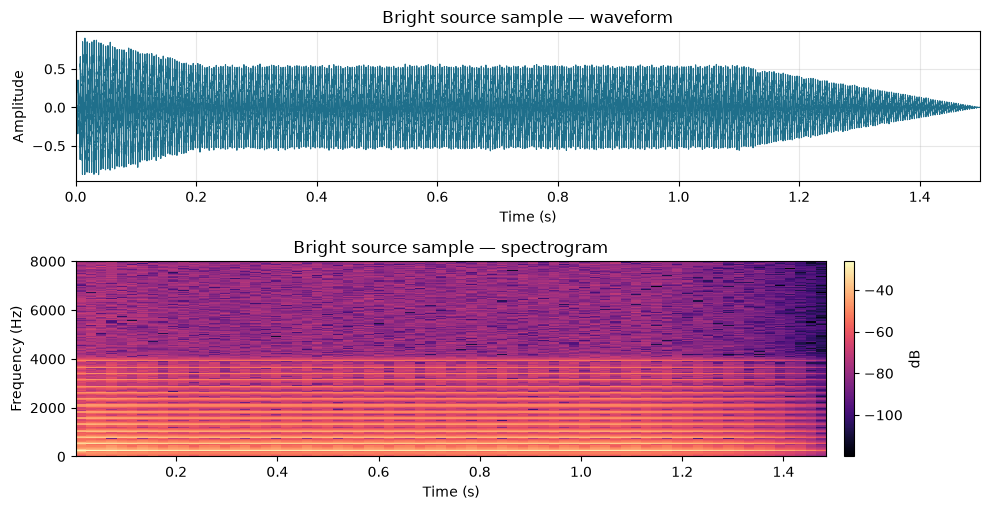

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, lfilter, freqz

from audio_utils import (
    SR, hear, normalize, seconds, midi_to_hz, apply_adsr,
    one_pole_lowpass, linear_resample, semitone_ratio,
)

def bright_sample(dur=1.5):
    t = np.arange(seconds(dur)) / SR
    f = midi_to_hz(60)
    y = sum((0.9 / k) * np.sin(2 * np.pi * f * k * t) for k in range(1, 16))
    y += 0.05 * np.random.default_rng(2).normal(0, 1, len(t))
    return apply_adsr(normalize(y), attack=0.01, decay=0.2, sustain=0.6, release=0.4)

src = bright_sample()
hear(src, SR, title="Bright source sample", show_spec=True)

## Low-pass tone control

Close the filter → darker sample (classic “cutoff” knob). Compare one-pole (cheap) vs. Butterworth (steeper).

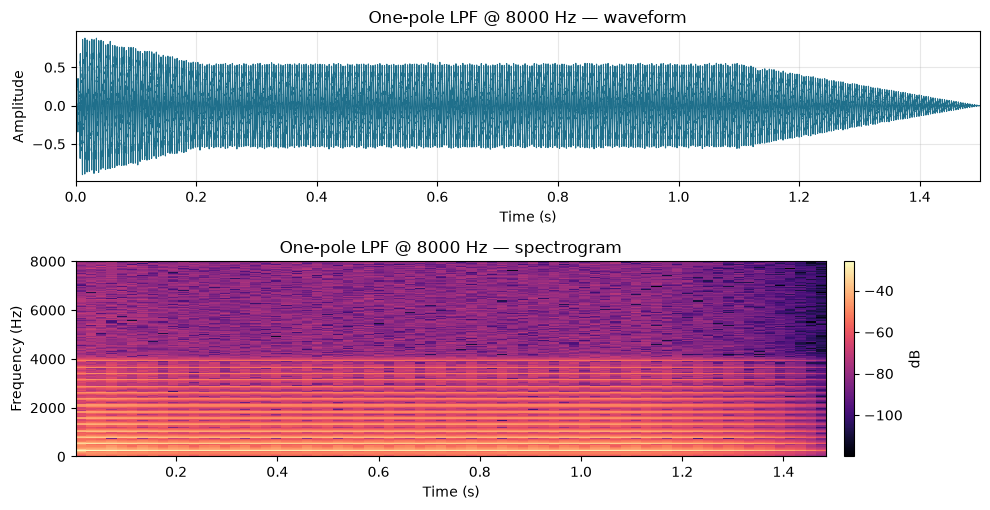

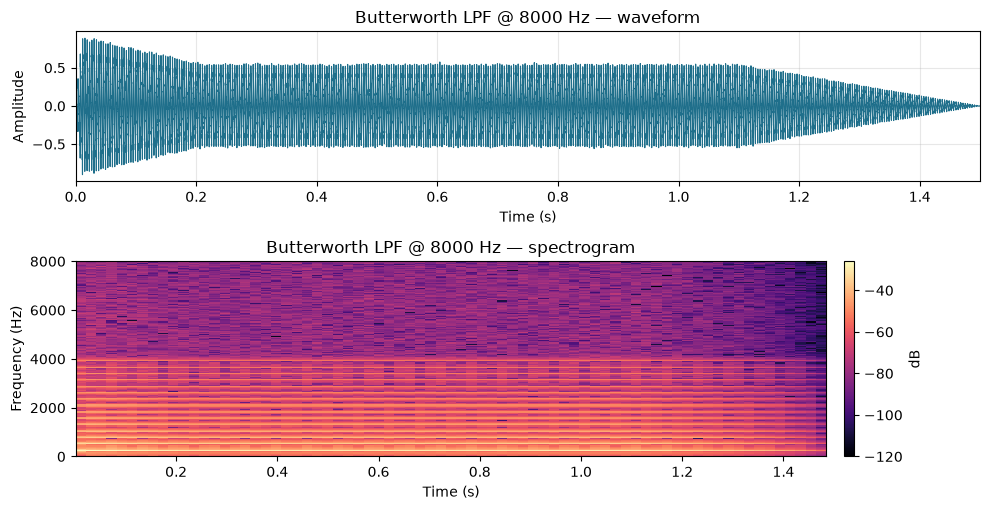

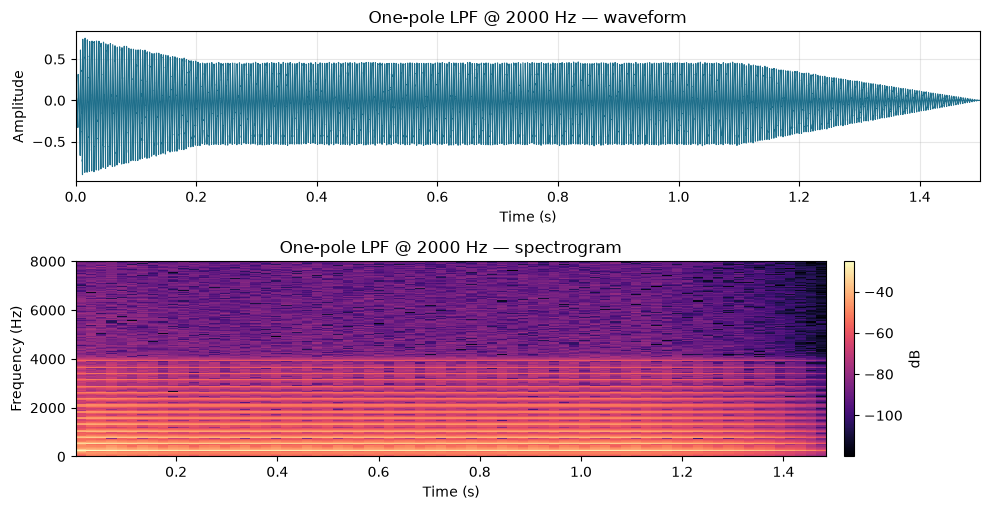

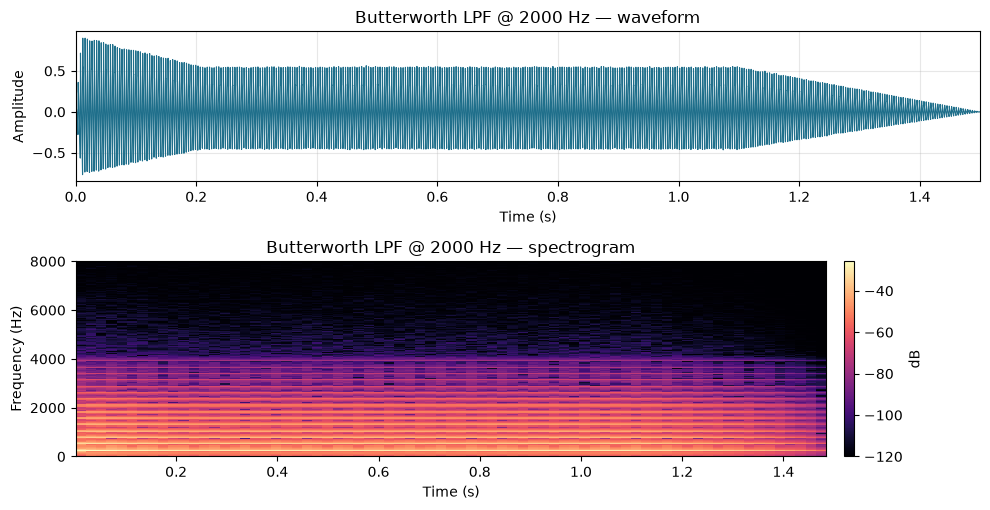

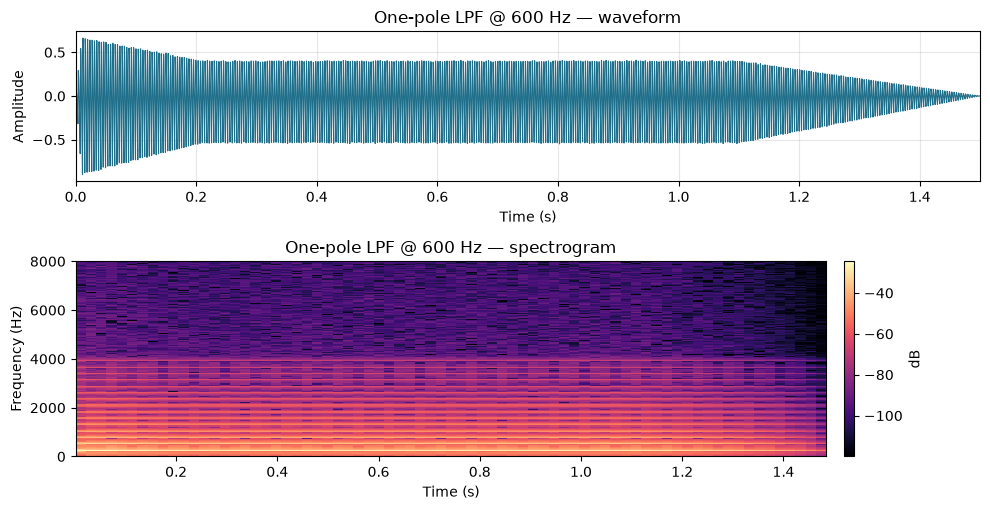

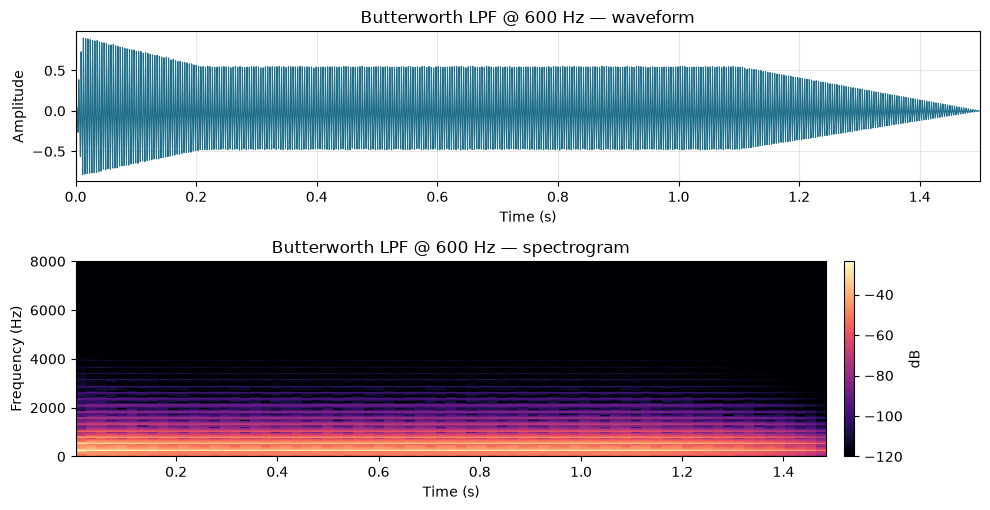

In [2]:
def butter_lowpass(x, cutoff, order=4):
    b, a = butter(order, cutoff / (SR / 2), btype="low")
    return lfilter(b, a, x)

for cutoff in [8000, 2000, 600]:
    a = one_pole_lowpass(src, cutoff)
    b = butter_lowpass(src, cutoff)
    hear(a, SR, title=f"One-pole LPF @ {cutoff} Hz", show_spec=True)
    hear(b, SR, title=f"Butterworth LPF @ {cutoff} Hz", show_spec=True)

## Filter sweep (envelope → cutoff)

Modulate cutoff over time — a staple of sampled bass / pad design.

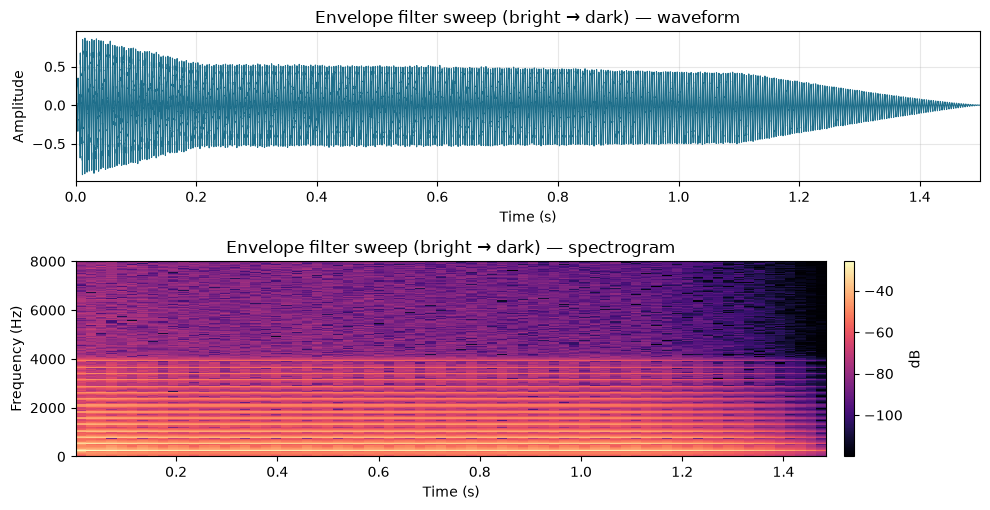

In [3]:
def sweeping_lpf(x, start_hz=4000, end_hz=300, sr=SR):
    x = np.asarray(x, dtype=np.float64).ravel()
    # Piecewise one-pole with slowly changing coefficient
    cutoffs = np.linspace(start_hz, end_hz, len(x))
    y = np.zeros_like(x)
    acc = 0.0
    for i, (sample, fc) in enumerate(zip(x, cutoffs)):
        coeff = np.exp(-2 * np.pi * fc / sr)
        acc = (1 - coeff) * sample + coeff * acc
        y[i] = acc
    return y

swept = sweeping_lpf(src, start_hz=6000, end_hz=250)
hear(swept, SR, title="Envelope filter sweep (bright → dark)", show_spec=True)

## Tempo delay / slapback

A feedback delay is the sampler’s friend for space without a full reverb algorithm.

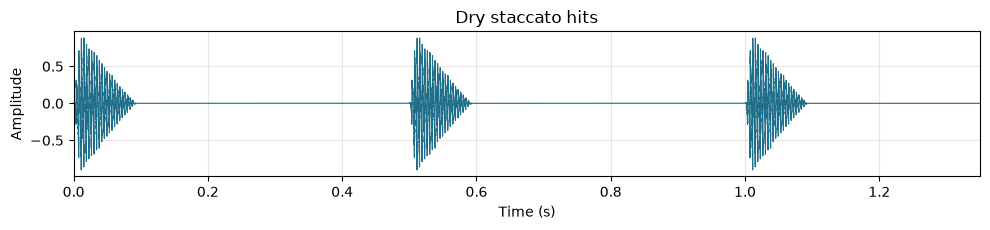

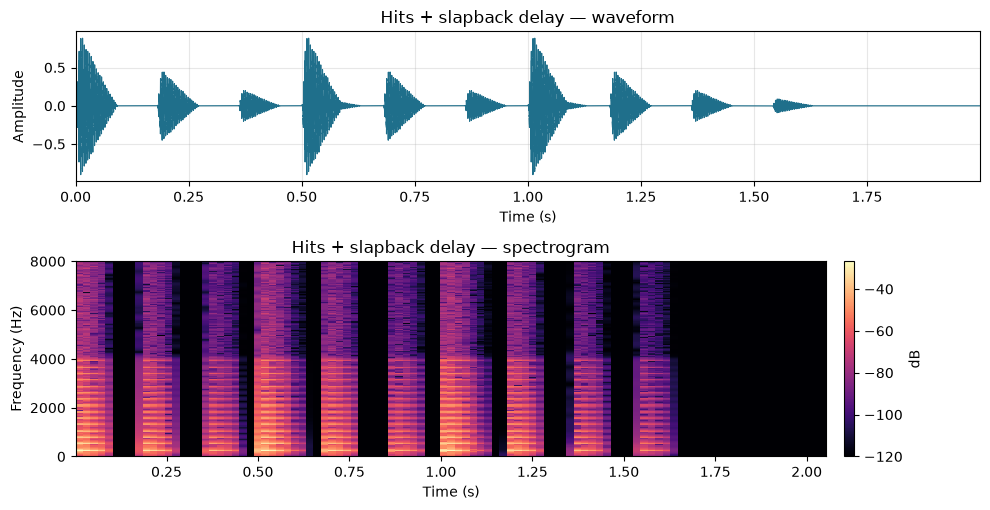

In [4]:
def delay_fx(x, delay_s=0.22, feedback=0.35, mix_amt=0.4):
    x = np.asarray(x, dtype=np.float64).ravel()
    d = seconds(delay_s)
    y = np.zeros(len(x) + d * 4)
    y[: len(x)] += x
    for i in range(len(x)):
        y[i + d] += mix_amt * x[i]
        if i + 2 * d < len(y):
            y[i + 2 * d] += mix_amt * feedback * x[i]
        if i + 3 * d < len(y):
            y[i + 3 * d] += mix_amt * feedback ** 2 * x[i]
    return normalize(y)

# Short staccato hits into delay
hit = apply_adsr(src[: seconds(0.35)], attack=0.005, decay=0.1, sustain=0.0, release=0.05)
phrase = np.concatenate([hit, np.zeros(seconds(0.15)), hit, np.zeros(seconds(0.15)), hit])
wet = delay_fx(phrase, delay_s=0.18, feedback=0.45, mix_amt=0.5)
hear(phrase, SR, title="Dry staccato hits")
hear(wet, SR, title="Hits + slapback delay", show_spec=True)

## LFO modulation

Low-frequency oscillators move parameters automatically — tremolo (amplitude) and wah-ish filter wobble.

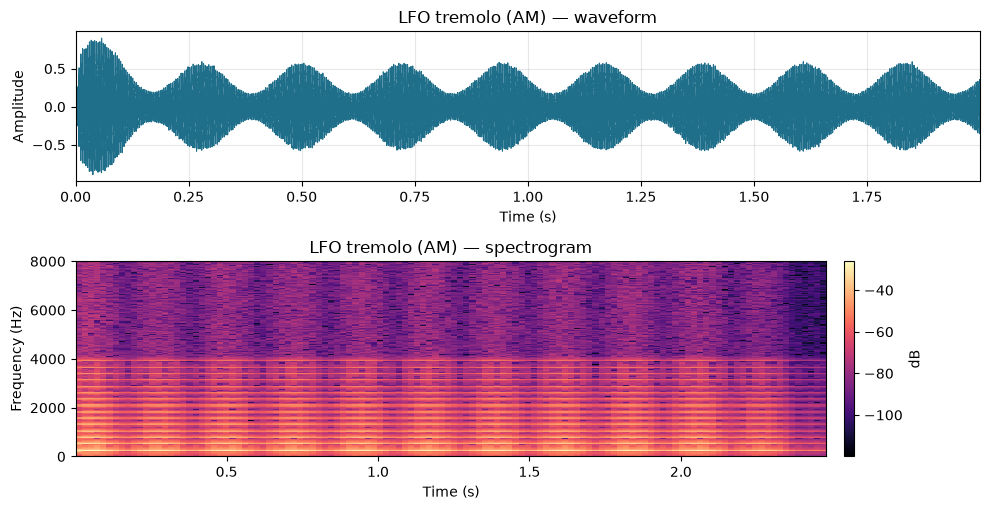

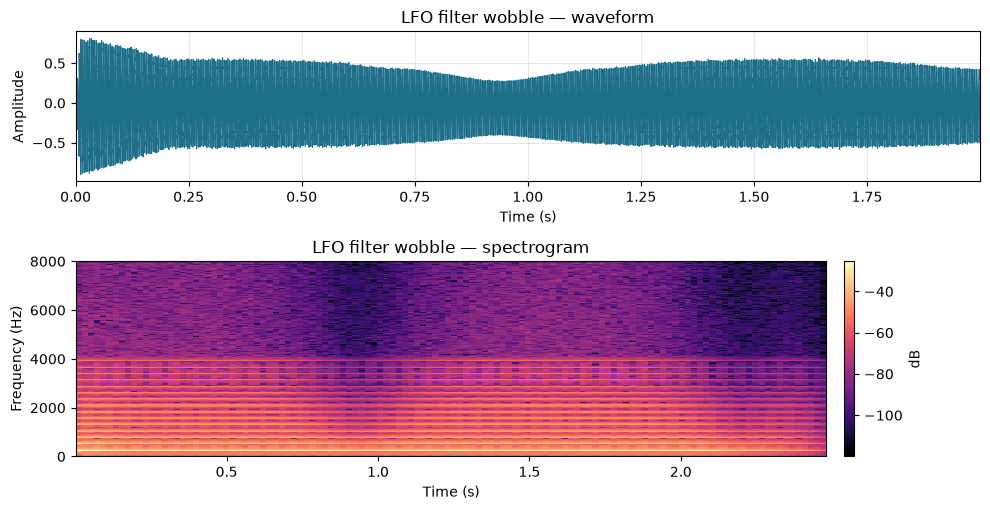

In [5]:
def tremolo(x, rate_hz=4.5, depth=0.7):
    t = np.arange(len(x)) / SR
    mod = (1 - depth) + depth * (0.5 * (1 + np.sin(2 * np.pi * rate_hz * t)))
    return x * mod

def lfo_filter(x, rate_hz=0.8, lo=400, hi=5000):
    t = np.arange(len(x)) / SR
    cutoffs = lo + (hi - lo) * (0.5 * (1 + np.sin(2 * np.pi * rate_hz * t)))
    y = np.zeros_like(x)
    acc = 0.0
    for i, (sample, fc) in enumerate(zip(x, cutoffs)):
        coeff = np.exp(-2 * np.pi * fc / SR)
        acc = (1 - coeff) * sample + coeff * acc
        y[i] = acc
    return y

pad = bright_sample(dur=2.5)
hear(tremolo(pad), SR, title="LFO tremolo (AM)", show_spec=True)
hear(lfo_filter(pad), SR, title="LFO filter wobble", show_spec=True)

## Chorus-ish thickening

Two slightly detuned delayed copies → width. Common on sampled strings / guitars.

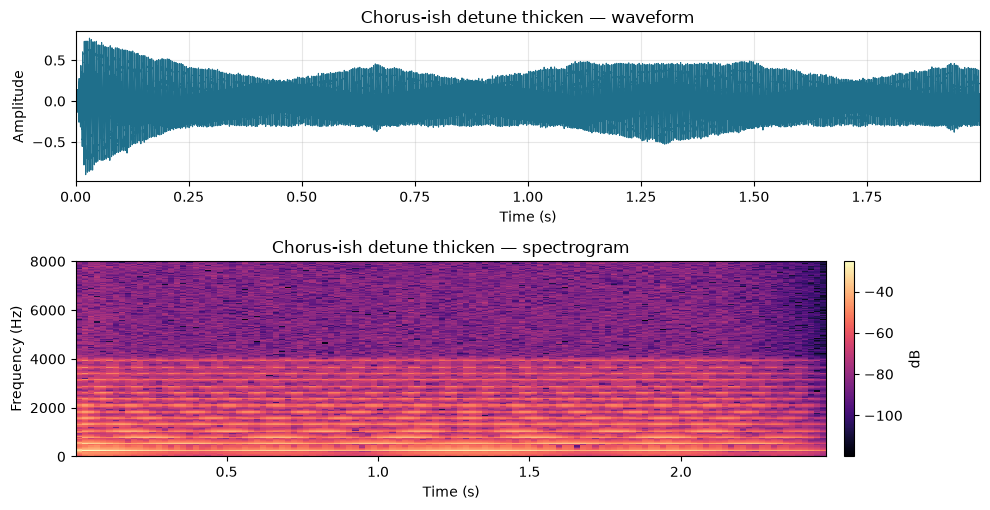

In [6]:
def chorusish(x, depths_ms=(7, 11), detune=(0.997, 1.003)):
    x = np.asarray(x, dtype=np.float64).ravel()
    parts = [x]
    for ms, det in zip(depths_ms, detune):
        delayed = np.concatenate([np.zeros(seconds(ms / 1000)), x])[: len(x)]
        tuned = linear_resample(delayed, det)
        if len(tuned) < len(x):
            tuned = np.pad(tuned, (0, len(x) - len(tuned)))
        parts.append(tuned[: len(x)])
    return normalize(np.sum(parts, axis=0))

hear(chorusish(pad), SR, title="Chorus-ish detune thicken", show_spec=True)

## You should be able to…

- Darken a sample with a low-pass and automate a sweep
- Add rhythmic space with a feedback delay
- Animate amplitude / cutoff with an LFO

**Next:** [05 — Mini sampler synth](05_mini_sampler_synth.ipynb)